In [ ]:
# Anchor the notebook to the repository root.
#
# Every path below (`data/`, `embeddings/`, the `.pth` weights and the
# `image_path` column stored in the CSVs) is relative to the repository root,
# not to this file. Walking up to the directory that holds `pyproject.toml`
# lets the notebook run from anywhere: `jupyter lab` at the root, from
# `notebooks/`, or from an IDE with its own working directory.
import os
from pathlib import Path

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

# Notebook Semi-Supervisé Optimisé — EfficientNet-B4 + SSL SOTA

Objectif : battre les baselines existantes (`model_supervised.pth` 0.833 acc, `model_phase1.pth` 0.800 acc, `model_phase2.pth` 0.900 acc) sur le val set (30 images) via 3 méthodes semi-supervisées modernes appliquées sur **EfficientNet-B4** (backbone gelé, classifier fine-tuné).

| Méthode | Principe | Référence |
|---------|----------|-----------|
| **Pseudo-Labeling itératif** | Auto-étiquetage des prédictions confiantes, ré-entraînement itéré | Lee 2013 |
| **Mean Teacher** | Cohérence Student/Teacher (EMA des poids) sur images non labellisées | Tarvainen & Valpola 2017 |
| **FixMatch** | Pseudo-labels confidence-thresholded sur vue *weak*, loss CE sur vue *strong* | Sohn et al. 2020 |

**Splits** : identiques à `Modelisations.ipynb` (70 train + 30 val sur les 100 labellisées, `random_state=42`).

**Données non labellisées** : les 1406 images de `pseudo_labels_gmm.csv` — les pseudo-labels GMM sont **ignorés** ici (c'est le rôle des méthodes SSL d'attribuer un label).

**Backbone gelé** : seul le classifier head (1792 → 2) est entraîné, par cohérence avec la Phase 2/3 de `Modelisations.ipynb`. Les méthodes SSL agissent donc sur la tête de classification uniquement.


## 1. Setup, imports et reproductibilité

In [1]:
import copy
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, adjusted_rand_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR = Path("notebooks/5_ssl_sota/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Torch  : {torch.__version__}")
print(f"Project root : {PROJECT_ROOT}")

Device : cuda
GPU    : NVIDIA GeForce RTX 5070
Torch  : 2.11.0+cu128
Project root : C:\Users\Kevin\projects\OC_P7


## 2. Chargement des données et splits

Reproduction **exacte** du split de `Modelisations.ipynb` :
- `unlabeled_df` (1406 images) ← `pseudo_labels_gmm.csv` → utilisées comme **non labellisées** pour SSL
- `labeled_train_df` (70 images) ← split stratifié `random_state=42`, `test_size=0.3` sur `true_labels_test.csv` → train labellisé
- `labeled_val_df` (30 images) ← second split → validation


In [2]:
unlabeled_df = pd.read_csv(PROJECT_ROOT / "pseudo_labels_gmm.csv")
test_df_full = pd.read_csv(PROJECT_ROOT / "true_labels_test.csv")

# Resolve relative paths from the notebook location
unlabeled_df["image_path"] = unlabeled_df["image_path"].apply(lambda p: str(PROJECT_ROOT / p))
test_df_full["image_path"] = test_df_full["image_path"].apply(lambda p: str(PROJECT_ROOT / p))

labeled_train_df, labeled_val_df = train_test_split(
    test_df_full,
    test_size=0.3,
    stratify=test_df_full["label"],
    random_state=SEED,
)

assert len(set(unlabeled_df["image_path"]) & set(test_df_full["image_path"])) == 0, "Data leakage"

print(f"Unlabeled (SSL pool)  : {len(unlabeled_df)} images")
print(f"Labeled train         : {len(labeled_train_df)} images "
      f"(cancer={(labeled_train_df['label']==1).sum()}, normal={(labeled_train_df['label']==0).sum()})")
print(f"Labeled val           : {len(labeled_val_df)} images "
      f"(cancer={(labeled_val_df['label']==1).sum()}, normal={(labeled_val_df['label']==0).sum()})")

Unlabeled (SSL pool)  : 1406 images
Labeled train         : 70 images (cancer=35, normal=35)
Labeled val           : 30 images (cancer=15, normal=15)


## 3. Transformations : weak / strong / inference

- **`transform_inference`** : Resize 224 + Normalize ImageNet (identique à `Modelisations.ipynb`)
- **`transform_weak`** : flip horizontal + crop reflect — augmentations légères pour le **Teacher** et la prédiction de pseudo-label
- **`transform_strong`** : weak + RandAugment + Cutout — augmentations agressives pour le **Student**


In [3]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class Cutout:
    """Random rectangular mask applied on a normalized tensor."""
    def __init__(self, n_holes=1, length=32):
        self.n_holes, self.length = n_holes, length

    def __call__(self, img):
        h, w = img.shape[1], img.shape[2]
        for _ in range(self.n_holes):
            y, x = np.random.randint(h), np.random.randint(w)
            y1, y2 = max(0, y - self.length // 2), min(h, y + self.length // 2)
            x1, x2 = max(0, x - self.length // 2), min(w, x + self.length // 2)
            img[:, y1:y2, x1:x2] = 0.0
        return img


transform_inference = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_weak = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(IMG_SIZE, padding=16, padding_mode="reflect"),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_strong = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(IMG_SIZE, padding=16, padding_mode="reflect"),
    transforms.RandAugment(num_ops=2, magnitude=10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    Cutout(n_holes=1, length=32),
])

print("Transforms prêts.")

Transforms prêts.


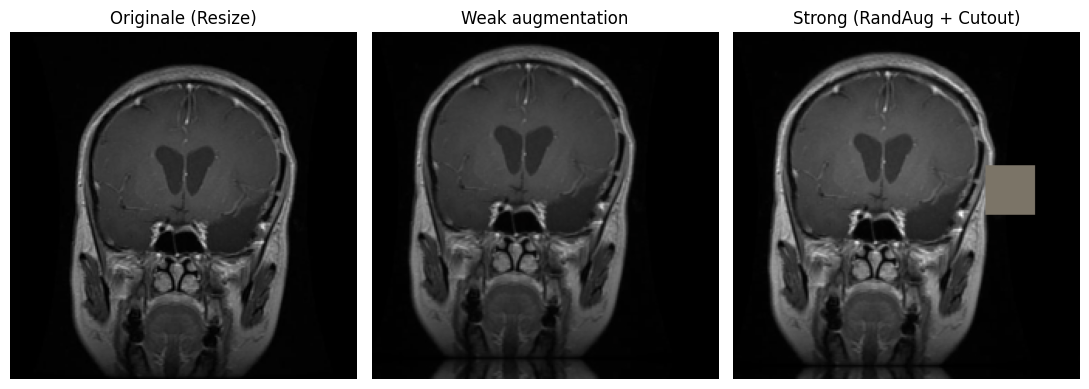

In [4]:
def denorm(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


sample_img = Image.open(labeled_train_df.iloc[0]["image_path"]).convert("RGB")
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(sample_img.resize((IMG_SIZE, IMG_SIZE))); axes[0].set_title("Originale (Resize)")
axes[1].imshow(denorm(transform_weak(sample_img)));      axes[1].set_title("Weak augmentation")
axes[2].imshow(denorm(transform_strong(sample_img)));    axes[2].set_title("Strong (RandAug + Cutout)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Datasets PyTorch et DataLoaders

In [5]:
class LabeledMRI(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        with Image.open(self.df.iloc[idx]["image_path"]) as img:
            x = self.transform(img.convert("RGB"))
        return x, int(self.df.iloc[idx]["label"])


class UnlabeledMRITwin(Dataset):
    """Returns (weak, strong) views of the same image — for FixMatch / Mean Teacher."""
    def __init__(self, df, transform_weak, transform_strong):
        self.df = df.reset_index(drop=True)
        self.tw, self.ts = transform_weak, transform_strong

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        with Image.open(self.df.iloc[idx]["image_path"]) as img:
            img = img.convert("RGB")
            return self.tw(img), self.ts(img)


class UnlabeledMRISingle(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        with Image.open(self.df.iloc[idx]["image_path"]) as img:
            x = self.transform(img.convert("RGB"))
        return x, idx

In [6]:
BATCH_LABELED = 16
BATCH_UNLABELED = 64

loader_train_weak = DataLoader(
    LabeledMRI(labeled_train_df, transform_weak),
    batch_size=BATCH_LABELED, shuffle=True, pin_memory=True,
)
loader_train_strong = DataLoader(
    LabeledMRI(labeled_train_df, transform_strong),
    batch_size=BATCH_LABELED, shuffle=True, pin_memory=True,
)
loader_val = DataLoader(
    LabeledMRI(labeled_val_df, transform_inference),
    batch_size=10, shuffle=False, pin_memory=True,
)
loader_unlabeled_twin = DataLoader(
    UnlabeledMRITwin(unlabeled_df, transform_weak, transform_strong),
    batch_size=BATCH_UNLABELED, shuffle=True, pin_memory=True, drop_last=True,
)

print(f"Train labeled   : {len(loader_train_weak)} batches × {BATCH_LABELED} (last batch may be smaller)")
print(f"Val             : {len(loader_val)} batches")
print(f"Unlabeled twin  : {len(loader_unlabeled_twin)} batches × {BATCH_UNLABELED}")

Train labeled   : 5 batches × 16 (last batch may be smaller)
Val             : 3 batches
Unlabeled twin  : 21 batches × 64


## 5. Backbone EfficientNet-B4 + utilitaires partagés

In [7]:
def build_efficientnet_b4(num_classes=2, dropout=0.4, freeze_backbone=True):
    """EfficientNet-B4 pretrained on ImageNet, classifier head replaced.

    With freeze_backbone=True only the classifier (1792 -> num_classes) is trainable.
    """
    model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    return model


def freeze_backbone_bn(model):
    """Force all BN layers in the frozen backbone to eval mode.

    Without this, model.train() would put BN into train mode and let
    running_mean/var drift away from the ImageNet pretrained statistics,
    silently corrupting the feature extractor across SSL training runs.
    Must be called AFTER each model.train() / student.train().
    """
    for m in model.features.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            m.eval()


_m = build_efficientnet_b4()
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
total = sum(p.numel() for p in _m.parameters())
print(f"EfficientNet-B4 — trainable {trainable:,} / total {total:,} ({100*trainable/total:.2f}%)")
del _m

EfficientNet-B4 — trainable 3,586 / total 17,552,202 (0.02%)


In [8]:
def evaluate(y_true, y_pred, title="Évaluation", show_plot=True):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    ari = adjusted_rand_score(y_true, y_pred)
    print(f"{'─'*40}\n  {title}\n{'─'*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  F2-score  : {f2:.4f}")
    print(f"  ARI       : {ari:.4f}\n")
    if show_plot:
        fig, ax = plt.subplots(figsize=(4, 4))
        ConfusionMatrixDisplay(
            confusion_matrix(y_true, y_pred),
            display_labels=["Normal (0)", "Cancer (1)"],
        ).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(title); plt.tight_layout(); plt.show()
    return {"accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "f2": f2, "ari": ari}


def predict_loader(model, loader, device=DEVICE):
    """Returns (y_true, y_pred, y_proba_cancer)."""
    model.eval()
    ys, ps, probas = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            prob = F.softmax(model(imgs), dim=1)
            ps.extend(prob.argmax(1).cpu().numpy())
            probas.extend(prob[:, 1].cpu().numpy())
            ys.extend(labels.numpy())
    return np.array(ys), np.array(ps), np.array(probas)

In [9]:
class GradCAM:
    """Grad-CAM with forward/backward hooks. Use as context manager."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._fwd = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach())
        )
        self._bwd = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach())
        )

    def __enter__(self): return self
    def __exit__(self, *a): self._fwd.remove(); self._bwd.remove()

    def __call__(self, img_tensor, class_idx):
        self.model.zero_grad()
        out = self.model(img_tensor)
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.cpu().numpy()


def overlay_gradcam(img_path, cam, alpha=0.5):
    img = np.array(Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    heatmap = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    blended = (alpha * heatmap_rgb + (1 - alpha) * img).astype(np.uint8)
    return img, blended


def plot_gradcam_errors(df, y_true, y_pred, gc_inst, error_type="FN"):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    if error_type == "FN":
        idxs = np.where((y_true == 1) & (y_pred == 0))[0]
        prefix, p_cls, t_cls = "FN — Cancer manqué", 0, 1
        c1, c2 = "Grad-CAM classe prédite (normal)", "Grad-CAM classe réelle (cancer)"
    else:
        idxs = np.where((y_true == 0) & (y_pred == 1))[0]
        prefix, p_cls, t_cls = "FP — Fausse alarme", 1, 0
        c1, c2 = "Grad-CAM classe prédite (cancer)", "Grad-CAM classe réelle (normal)"
    if len(idxs) == 0:
        print(f"Aucune erreur {error_type}.")
        return
    n = len(idxs)
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3.2))
    if n == 1: axes = [axes]
    fig.suptitle(f"{prefix} — Grad-CAM", fontsize=13, fontweight="bold", color="#e74c3c")
    fig.subplots_adjust(top=0.88)
    gc_inst.model.eval()
    for r, idx in enumerate(idxs):
        path = df.iloc[idx]["image_path"]
        t = transform_inference(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
        cam_p = gc_inst(t.requires_grad_(True), p_cls)
        orig, ov_p = overlay_gradcam(path, cam_p)
        cam_t = gc_inst(t.detach().requires_grad_(True), t_cls)
        _, ov_t = overlay_gradcam(path, cam_t)
        axes[r][0].imshow(orig); axes[r][0].set_title("Image originale", fontsize=9); axes[r][0].axis("off")
        axes[r][1].imshow(ov_p); axes[r][1].set_title(c1, fontsize=9); axes[r][1].axis("off")
        axes[r][2].imshow(ov_t); axes[r][2].set_title(c2, fontsize=9); axes[r][2].axis("off")
    plt.tight_layout(); plt.show()


def run_gradcam_analysis(model, df, y_true, y_pred, phase=""):
    """Grad-CAM on EfficientNet-B4: target = last block of model.features."""
    suffix = f" — {phase}" if phase else ""
    was_frozen = [p.requires_grad for p in model.features.parameters()]
    for p in model.features.parameters(): p.requires_grad_(True)
    target = model.features[-1]
    try:
        with GradCAM(model, target) as gc:
            print(f"Grad-CAM{suffix} — FN :")
            plot_gradcam_errors(df, y_true, y_pred, gc, "FN")
            print(f"Grad-CAM{suffix} — FP :")
            plot_gradcam_errors(df, y_true, y_pred, gc, "FP")
    finally:
        # Restore frozen state and clear any accumulated gradients
        for p, r in zip(model.features.parameters(), was_frozen):
            p.requires_grad_(r)
        model.zero_grad(set_to_none=True)


def save_checkpoint(model, name, metrics=None, **extra):
    payload = {"state_dict": model.state_dict()}
    if metrics is not None:
        payload["metrics"] = metrics
    payload.update(extra)
    torch.save(payload, CHECKPOINT_DIR / f"{name}.pth")


def load_checkpoint(model, name, device=DEVICE):
    payload = torch.load(CHECKPOINT_DIR / f"{name}.pth", map_location=device, weights_only=False)
    model.load_state_dict(payload["state_dict"])
    return payload

## 6. Baseline supervisée — EfficientNet-B4 sur 70 labels (backbone gelé)

Équivalent à la **Phase 3** de `Modelisations.ipynb` mais avec EfficientNet-B4 + ImageNet à la place de MyCNN. Sert de point de départ (warm start) pour les 3 méthodes SSL.


In [10]:
def train_supervised(model, loader_train, loader_val, epochs, lr=1e-3,
                     weight_decay=1e-4, name="baseline_supervised"):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=weight_decay,
    )
    crit = nn.CrossEntropyLoss()
    history, best_acc, best_metrics = [], 0.0, None
    pbar = tqdm(range(epochs), desc=name)
    for ep in pbar:
        model.train()
        freeze_backbone_bn(model)  # keep ImageNet BN stats frozen
        train_loss = 0.0
        for imgs, labels in loader_train:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).long()
            opt.zero_grad()
            loss = crit(model(imgs), labels)
            loss.backward(); opt.step()
            train_loss += loss.item()
        train_loss /= len(loader_train)
        y, p, _ = predict_loader(model, loader_val)
        val_acc = accuracy_score(y, p)
        val_f1 = f1_score(y, p, zero_division=0)
        history.append({"epoch": ep + 1, "train_loss": train_loss,
                        "val_acc": val_acc, "val_f1": val_f1})
        pbar.set_postfix(loss=f"{train_loss:.3f}", val_acc=f"{val_acc:.3f}", val_f1=f"{val_f1:.3f}")
        if val_acc > best_acc:
            best_acc = val_acc
            best_metrics = {"val_acc": val_acc, "val_f1": val_f1, "epoch": ep + 1}
            save_checkpoint(model, name, metrics=best_metrics)
    return pd.DataFrame(history), best_metrics


print("=== Baseline EfficientNet-B4 supervisé (70 labels, backbone gelé) ===")
model_baseline = build_efficientnet_b4()
hist_baseline, best_baseline = train_supervised(
    model_baseline, loader_train_strong, loader_val,
    epochs=30, lr=1e-3, weight_decay=1e-4, name="baseline_supervised",
)
print(f"\nBest val_acc : {best_baseline['val_acc']:.4f} (epoch {best_baseline['epoch']})")

=== Baseline EfficientNet-B4 supervisé (70 labels, backbone gelé) ===


baseline_supervised: 100%|██████████| 30/30 [00:13<00:00,  2.26it/s, loss=0.225, val_acc=0.933, val_f1=0.933]


Best val_acc : 0.9667 (epoch 13)


────────────────────────────────────────
  Baseline EfficientNet-B4 (70 labels)
────────────────────────────────────────
  Accuracy  : 0.9667
  Precision : 1.0000
  Recall    : 0.9333
  F1-score  : 0.9655
  F2-score  : 0.9459
  ARI       : 0.8665



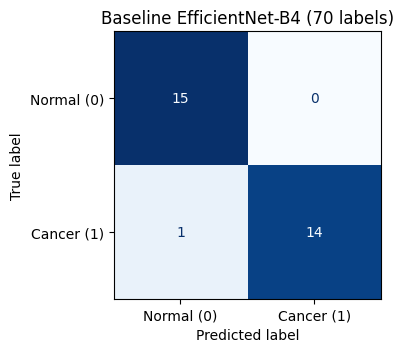

Grad-CAM — Baseline — FN :


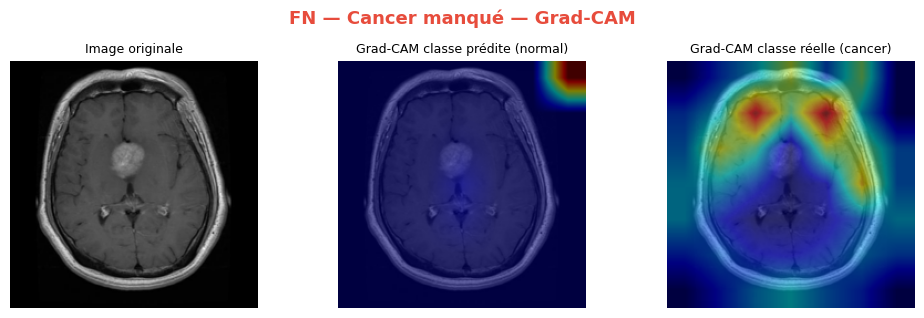

Grad-CAM — Baseline — FP :
Aucune erreur FP.


In [11]:
load_checkpoint(model_baseline, "baseline_supervised")
y_true_b, y_pred_b, _ = predict_loader(model_baseline, loader_val)
results_baseline = evaluate(y_true_b, y_pred_b, title="Baseline EfficientNet-B4 (70 labels)")
run_gradcam_analysis(
    model_baseline, labeled_val_df.reset_index(drop=True),
    y_true_b, y_pred_b, phase="Baseline",
)

## 7. Méthode 1 — Pseudo-Labeling itératif

À chaque itération :
1. Prédire sur les 1406 unlabeled
2. Garder uniquement celles dont `max(softmax) ≥ τ = 0.95`
3. Ajouter au train et ré-entraîner le classifier head
4. Recommencer (warm start depuis baseline)

**Risque** : confirmation bias. Le seuil élevé limite l'effet, mais on monitore la distribution par classe à chaque itération.


In [12]:
def generate_pseudo_labels(model, df_unlabeled, threshold=0.95):
    """Returns DataFrame of confident predictions on the unlabeled pool."""
    loader = DataLoader(
        UnlabeledMRISingle(df_unlabeled, transform_inference),
        batch_size=BATCH_UNLABELED, shuffle=False, pin_memory=True,
    )
    model.eval()
    paths, labels, confs = [], [], []
    with torch.no_grad():
        for imgs, idxs in loader:
            imgs = imgs.to(DEVICE)
            probs = F.softmax(model(imgs), dim=1)
            max_p, pred = probs.max(dim=1)
            mask = max_p >= threshold
            for i, m in enumerate(mask):
                if m.item():
                    paths.append(df_unlabeled.iloc[idxs[i].item()]["image_path"])
                    labels.append(int(pred[i].item()))
                    confs.append(float(max_p[i].item()))
    return pd.DataFrame({"image_path": paths, "label": labels, "confidence": confs})


Iter 1 — pseudo-labels : 33 / 1406 (cancer=28, normal=5)
  Val acc : 0.9667 | F1 : 0.9655

Iter 2 — pseudo-labels : 35 / 1406 (cancer=30, normal=5)
  Val acc : 0.9667 | F1 : 0.9655

Iter 3 — pseudo-labels : 42 / 1406 (cancer=36, normal=6)
  Val acc : 0.9667 | F1 : 0.9655

Iter 4 — pseudo-labels : 49 / 1406 (cancer=42, normal=7)
  Val acc : 0.9667 | F1 : 0.9655

Iter 5 — pseudo-labels : 63 / 1406 (cancer=56, normal=7)
  Val acc : 0.9667 | F1 : 0.9655

Best iter : 1 | val_acc : 0.9667


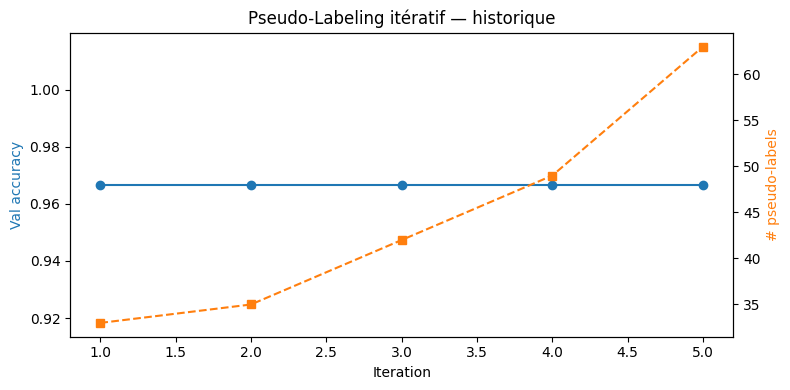

In [13]:
N_ITER_PL = 5
EPOCHS_PER_ITER_PL = 5
THRESHOLD_PL = 0.95

model_pl = build_efficientnet_b4().to(DEVICE)
load_checkpoint(model_pl, "baseline_supervised")

history_pl = []
best_acc_pl, best_iter_pl = 0.0, 0

for it in range(1, N_ITER_PL + 1):
    pseudo_df = generate_pseudo_labels(model_pl, unlabeled_df, threshold=THRESHOLD_PL)
    n_cancer = (pseudo_df["label"] == 1).sum()
    n_normal = (pseudo_df["label"] == 0).sum()
    print(f"\nIter {it} — pseudo-labels : {len(pseudo_df)} / {len(unlabeled_df)} "
          f"(cancer={n_cancer}, normal={n_normal})")
    if len(pseudo_df) == 0:
        print("Aucun pseudo-label confiant — arrêt.")
        break

    combined_df = pd.concat(
        [labeled_train_df[["image_path", "label"]], pseudo_df[["image_path", "label"]]],
        ignore_index=True,
    )
    loader_combined = DataLoader(
        LabeledMRI(combined_df, transform_strong),
        batch_size=32, shuffle=True, pin_memory=True, drop_last=True,
    )
    opt = torch.optim.AdamW(
        [p for p in model_pl.parameters() if p.requires_grad],
        lr=5e-5, weight_decay=1e-4,
    )
    crit = nn.CrossEntropyLoss()
    for ep in range(EPOCHS_PER_ITER_PL):
        model_pl.train()
        freeze_backbone_bn(model_pl)  # keep ImageNet BN stats frozen
        for imgs, lbls in loader_combined:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE).long()
            opt.zero_grad()
            crit(model_pl(imgs), lbls).backward()
            opt.step()

    y, p, _ = predict_loader(model_pl, loader_val)
    val_acc = accuracy_score(y, p)
    val_f1 = f1_score(y, p, zero_division=0)
    print(f"  Val acc : {val_acc:.4f} | F1 : {val_f1:.4f}")
    history_pl.append({"iter": it, "n_pseudo": len(pseudo_df),
                       "val_acc": val_acc, "val_f1": val_f1})
    if val_acc > best_acc_pl:
        best_acc_pl, best_iter_pl = val_acc, it
        save_checkpoint(model_pl, "pseudo_labeling_best",
                        metrics={"val_acc": val_acc, "val_f1": val_f1, "iter": it})

history_pl = pd.DataFrame(history_pl)
history_pl.to_csv(CHECKPOINT_DIR / "history_pseudo_labeling.csv", index=False)
print(f"\nBest iter : {best_iter_pl} | val_acc : {best_acc_pl:.4f}")

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(history_pl["iter"], history_pl["val_acc"], "o-", color="tab:blue", label="val_acc")
ax2.plot(history_pl["iter"], history_pl["n_pseudo"], "s--", color="tab:orange", label="n_pseudo")
ax1.set_xlabel("Iteration"); ax1.set_ylabel("Val accuracy", color="tab:blue")
ax2.set_ylabel("# pseudo-labels", color="tab:orange")
ax1.set_title("Pseudo-Labeling itératif — historique")
plt.tight_layout(); plt.show()

────────────────────────────────────────
  Pseudo-Labeling itératif
────────────────────────────────────────
  Accuracy  : 0.9667
  Precision : 1.0000
  Recall    : 0.9333
  F1-score  : 0.9655
  F2-score  : 0.9459
  ARI       : 0.8665



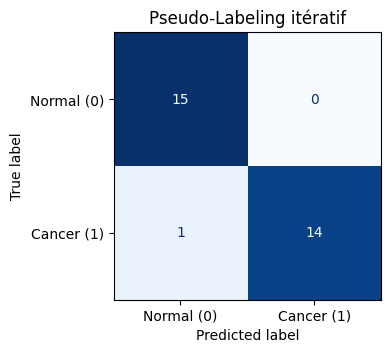

Grad-CAM — Pseudo-Labeling — FN :


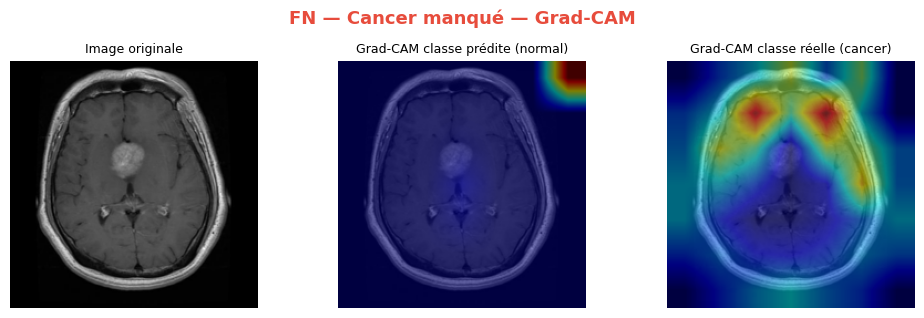

Grad-CAM — Pseudo-Labeling — FP :
Aucune erreur FP.


In [14]:
load_checkpoint(model_pl, "pseudo_labeling_best")
y_true_pl, y_pred_pl, _ = predict_loader(model_pl, loader_val)
results_pl = evaluate(y_true_pl, y_pred_pl, title="Pseudo-Labeling itératif")
run_gradcam_analysis(
    model_pl, labeled_val_df.reset_index(drop=True),
    y_true_pl, y_pred_pl, phase="Pseudo-Labeling",
)

## 8. Méthode 2 — Mean Teacher

- **Student** : reçoit augmentations strong, entraîné par gradient
- **Teacher** : copie EMA des poids du Student (`α = 0.999`), reçoit augmentations weak
- Loss = `CE(Student(labeled)) + λ(t) · MSE(softmax(Student(strong)), softmax(Teacher(weak)))`
- λ(t) suit un sigmoid rampup sur 10 epochs (évite de polluer le training avant que le Teacher soit stable)

**Critique** : il faut EMA aussi les buffers (BatchNorm running stats), sinon le Teacher diverge complètement en eval.


In [15]:
def update_ema(student, teacher, alpha):
    with torch.no_grad():
        for tp, sp in zip(teacher.parameters(), student.parameters()):
            tp.data.mul_(alpha).add_(sp.data, alpha=1 - alpha)
        # EMA buffers (BatchNorm running stats) — critical
        for tb, sb in zip(teacher.buffers(), student.buffers()):
            if tb.dtype.is_floating_point:
                tb.data.mul_(alpha).add_(sb.data, alpha=1 - alpha)
            else:
                tb.data.copy_(sb.data)


def create_teacher(student):
    teacher = copy.deepcopy(student)
    for p in teacher.parameters():
        p.requires_grad_(False)
    return teacher


def sigmoid_rampup(current, rampup_length):
    if rampup_length == 0:
        return 1.0
    current = float(np.clip(current, 0.0, rampup_length))
    phase = 1.0 - current / rampup_length
    return float(np.exp(-5.0 * phase * phase))

Ep 01 | sup=0.267 | cons=0.0082 | w=0.007 | teacher val_acc=0.967 F1=0.966


Ep 02 | sup=0.241 | cons=0.0088 | w=0.017 | teacher val_acc=0.967 F1=0.966


Ep 03 | sup=0.292 | cons=0.0079 | w=0.041 | teacher val_acc=0.967 F1=0.966


Ep 04 | sup=0.262 | cons=0.0119 | w=0.086 | teacher val_acc=0.967 F1=0.966


Ep 05 | sup=0.310 | cons=0.0098 | w=0.165 | teacher val_acc=0.967 F1=0.966


...

Ep 26 | sup=0.285 | cons=0.0097 | w=1.000 | teacher val_acc=0.967 F1=0.966


Ep 27 | sup=0.307 | cons=0.0091 | w=1.000 | teacher val_acc=0.967 F1=0.966


Ep 28 | sup=0.282 | cons=0.0106 | w=1.000 | teacher val_acc=0.967 F1=0.966


Ep 29 | sup=0.331 | cons=0.0093 | w=1.000 | teacher val_acc=0.967 F1=0.966


Ep 30 | sup=0.279 | cons=0.0096 | w=1.000 | teacher val_acc=0.967 F1=0.966

Best teacher val_acc : 0.9667 (epoch 1)


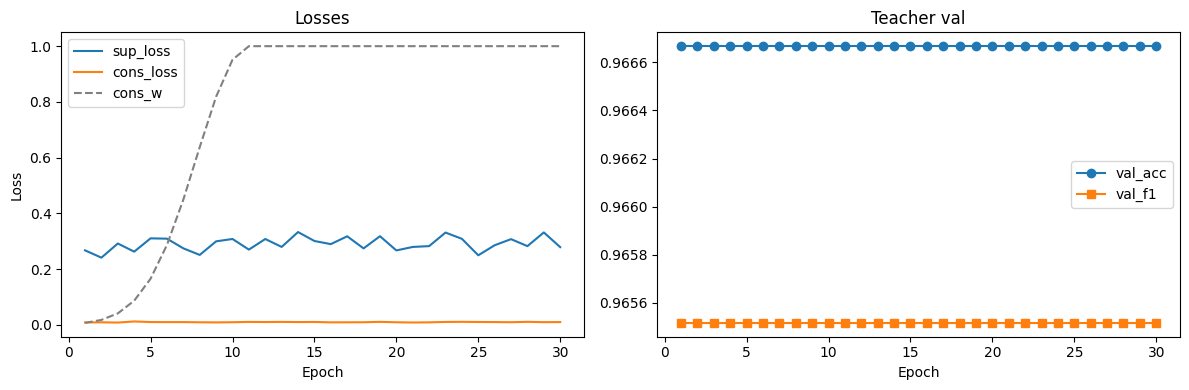

In [16]:
EPOCHS_MT = 30
EMA_ALPHA = 0.999
CONS_W_MAX = 1.0
RAMPUP_EPOCHS = 10

student = build_efficientnet_b4().to(DEVICE)
load_checkpoint(student, "baseline_supervised")
teacher = create_teacher(student)

opt = torch.optim.AdamW(
    [p for p in student.parameters() if p.requires_grad],
    lr=3e-5, weight_decay=1e-4,
)
crit_sup = nn.CrossEntropyLoss()

iter_unlab = iter(loader_unlabeled_twin)
hist_mt, best_mt_acc, best_mt_metrics = [], 0.0, None

for ep in range(EPOCHS_MT):
    student.train(); freeze_backbone_bn(student)
    teacher.eval()
    sup_sum, cons_sum, n_steps = 0.0, 0.0, 0
    cons_w = CONS_W_MAX * sigmoid_rampup(ep, RAMPUP_EPOCHS)
    # Use strong augmentation on the labeled supervised step (consistent with baseline)
    pbar = tqdm(loader_train_strong, desc=f"MT ep {ep+1}/{EPOCHS_MT}", leave=False)
    for x_lab, y_lab in pbar:
        try:
            x_w, x_s = next(iter_unlab)
        except StopIteration:
            iter_unlab = iter(loader_unlabeled_twin)
            x_w, x_s = next(iter_unlab)
        x_lab, y_lab = x_lab.to(DEVICE), y_lab.to(DEVICE).long()
        x_w, x_s = x_w.to(DEVICE), x_s.to(DEVICE)

        loss_sup = crit_sup(student(x_lab), y_lab)
        with torch.no_grad():
            probs_t = F.softmax(teacher(x_w), dim=1)
        probs_s = F.softmax(student(x_s), dim=1)
        loss_cons = F.mse_loss(probs_s, probs_t)

        loss = loss_sup + cons_w * loss_cons
        opt.zero_grad(); loss.backward(); opt.step()
        update_ema(student, teacher, EMA_ALPHA)

        sup_sum += loss_sup.item()
        cons_sum += loss_cons.item()
        n_steps += 1

    y, p, _ = predict_loader(teacher, loader_val)
    val_acc = accuracy_score(y, p); val_f1 = f1_score(y, p, zero_division=0)
    hist_mt.append({"epoch": ep + 1, "sup_loss": sup_sum / n_steps,
                    "cons_loss": cons_sum / n_steps, "cons_w": cons_w,
                    "val_acc": val_acc, "val_f1": val_f1})
    print(f"Ep {ep+1:02d} | sup={sup_sum/n_steps:.3f} | cons={cons_sum/n_steps:.4f} "
          f"| w={cons_w:.3f} | teacher val_acc={val_acc:.3f} F1={val_f1:.3f}")
    if val_acc > best_mt_acc:
        best_mt_acc = val_acc
        best_mt_metrics = {"val_acc": val_acc, "val_f1": val_f1, "epoch": ep + 1}
        save_checkpoint(teacher, "mean_teacher_best", metrics=best_mt_metrics)

hist_mt = pd.DataFrame(hist_mt)
hist_mt.to_csv(CHECKPOINT_DIR / "history_mean_teacher.csv", index=False)
print(f"\nBest teacher val_acc : {best_mt_acc:.4f} (epoch {best_mt_metrics['epoch']})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_mt["epoch"], hist_mt["sup_loss"], label="sup_loss")
ax[0].plot(hist_mt["epoch"], hist_mt["cons_loss"], label="cons_loss")
ax[0].plot(hist_mt["epoch"], hist_mt["cons_w"], "--", color="gray", label="cons_w")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].set_title("Losses")
ax[1].plot(hist_mt["epoch"], hist_mt["val_acc"], "o-", label="val_acc")
ax[1].plot(hist_mt["epoch"], hist_mt["val_f1"], "s-", label="val_f1")
ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].set_title("Teacher val")
plt.tight_layout(); plt.show()

────────────────────────────────────────
  Mean Teacher
────────────────────────────────────────
  Accuracy  : 0.9667
  Precision : 1.0000
  Recall    : 0.9333
  F1-score  : 0.9655
  F2-score  : 0.9459
  ARI       : 0.8665



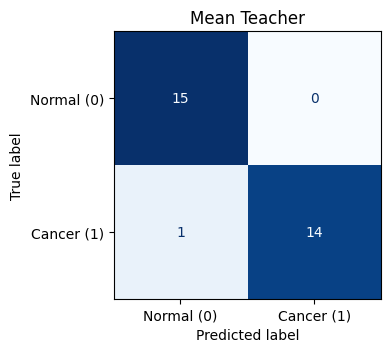

Grad-CAM — Mean Teacher — FN :


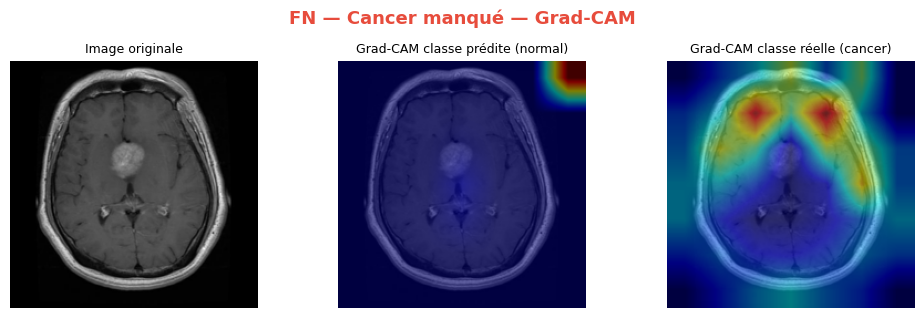

Grad-CAM — Mean Teacher — FP :
Aucune erreur FP.


In [17]:
mt_model = build_efficientnet_b4().to(DEVICE)
load_checkpoint(mt_model, "mean_teacher_best")
y_true_mt, y_pred_mt, _ = predict_loader(mt_model, loader_val)
results_mt = evaluate(y_true_mt, y_pred_mt, title="Mean Teacher")
run_gradcam_analysis(
    mt_model, labeled_val_df.reset_index(drop=True),
    y_true_mt, y_pred_mt, phase="Mean Teacher",
)

## 9. Méthode 3 — FixMatch (SOTA)

À chaque step :
1. Prédiction sur version **weak** d'une image unlabeled → si confidence ≥ τ = 0.95, on génère un **pseudo-label hard**
2. Loss CE entre prédiction sur version **strong** et ce pseudo-label
3. + Loss CE supervisée standard

`loss = loss_sup + λ_u · loss_unsup` avec λ_u = 1.0. Forward concaténé pour efficacité GPU.

**Métrique clé** : `mask_ratio` = % de pseudo-labels acceptés. Si <10% en fin de training → seuil trop élevé ou modèle pas assez confiant.


Ep 01 | sup=0.283 | unsup=0.007 | mask=5.94% | val_acc=0.933


Ep 02 | sup=0.282 | unsup=0.004 | mask=3.44% | val_acc=0.933


Ep 03 | sup=0.268 | unsup=0.010 | mask=9.69% | val_acc=0.967


Ep 04 | sup=0.216 | unsup=0.014 | mask=21.56% | val_acc=0.967


Ep 05 | sup=0.185 | unsup=0.023 | mask=34.06% | val_acc=0.967


...

Ep 26 | sup=0.079 | unsup=0.031 | mask=51.25% | val_acc=0.933


Ep 27 | sup=0.106 | unsup=0.019 | mask=49.69% | val_acc=0.933


Ep 28 | sup=0.115 | unsup=0.024 | mask=47.50% | val_acc=0.933


Ep 29 | sup=0.084 | unsup=0.038 | mask=50.94% | val_acc=0.933


Ep 30 | sup=0.120 | unsup=0.020 | mask=50.62% | val_acc=0.933

Best val_acc : 0.9667 (epoch 3)


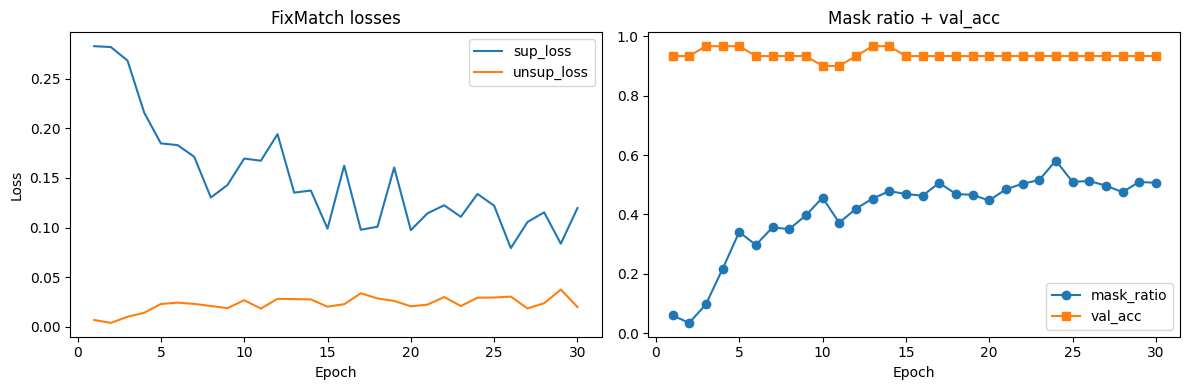

In [18]:
EPOCHS_FM = 30
THRESHOLD_FM = 0.95
LAMBDA_U = 1.0

model_fm = build_efficientnet_b4().to(DEVICE)
load_checkpoint(model_fm, "baseline_supervised")

opt = torch.optim.SGD(
    [p for p in model_fm.parameters() if p.requires_grad],
    lr=0.03, momentum=0.9, nesterov=True, weight_decay=5e-4,
)
total_steps = EPOCHS_FM * len(loader_train_weak)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_steps)
crit_sup = nn.CrossEntropyLoss()

iter_unlab = iter(loader_unlabeled_twin)
hist_fm, best_fm_acc, best_fm_metrics = [], 0.0, None

for ep in range(EPOCHS_FM):
    model_fm.train(); freeze_backbone_bn(model_fm)
    sup_sum, unsup_sum, mask_sum, n_steps = 0.0, 0.0, 0.0, 0
    pbar = tqdm(loader_train_weak, desc=f"FM ep {ep+1}/{EPOCHS_FM}", leave=False)
    for x_lab, y_lab in pbar:
        try:
            x_w, x_s = next(iter_unlab)
        except StopIteration:
            iter_unlab = iter(loader_unlabeled_twin)
            x_w, x_s = next(iter_unlab)
        x_lab, y_lab = x_lab.to(DEVICE), y_lab.to(DEVICE).long()
        x_w, x_s = x_w.to(DEVICE), x_s.to(DEVICE)
        B_lab, B_unlab = x_lab.size(0), x_w.size(0)

        inputs = torch.cat([x_lab, x_w, x_s], dim=0)
        logits = model_fm(inputs)
        logits_lab = logits[:B_lab]
        logits_w = logits[B_lab:B_lab + B_unlab]
        logits_s = logits[B_lab + B_unlab:]

        loss_sup = crit_sup(logits_lab, y_lab)
        with torch.no_grad():
            # Detach to be explicit: pseudo-label generation must not flow gradients
            probs_w = F.softmax(logits_w.detach(), dim=1)
            max_p, pseudo = probs_w.max(dim=1)
            mask = (max_p >= THRESHOLD_FM).float()
        loss_unsup = (F.cross_entropy(logits_s, pseudo, reduction="none") * mask).mean()
        loss = loss_sup + LAMBDA_U * loss_unsup

        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        sup_sum += loss_sup.item()
        unsup_sum += loss_unsup.item()
        mask_sum += mask.mean().item()
        n_steps += 1

    y, p, _ = predict_loader(model_fm, loader_val)
    val_acc = accuracy_score(y, p); val_f1 = f1_score(y, p, zero_division=0)
    hist_fm.append({"epoch": ep + 1, "sup_loss": sup_sum / n_steps,
                    "unsup_loss": unsup_sum / n_steps, "mask_ratio": mask_sum / n_steps,
                    "val_acc": val_acc, "val_f1": val_f1})
    print(f"Ep {ep+1:02d} | sup={sup_sum/n_steps:.3f} | unsup={unsup_sum/n_steps:.3f} "
          f"| mask={mask_sum/n_steps:.2%} | val_acc={val_acc:.3f}")
    if val_acc > best_fm_acc:
        best_fm_acc = val_acc
        best_fm_metrics = {"val_acc": val_acc, "val_f1": val_f1, "epoch": ep + 1}
        save_checkpoint(model_fm, "fixmatch_best", metrics=best_fm_metrics)

hist_fm = pd.DataFrame(hist_fm)
hist_fm.to_csv(CHECKPOINT_DIR / "history_fixmatch.csv", index=False)
print(f"\nBest val_acc : {best_fm_acc:.4f} (epoch {best_fm_metrics['epoch']})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_fm["epoch"], hist_fm["sup_loss"], label="sup_loss")
ax[0].plot(hist_fm["epoch"], hist_fm["unsup_loss"], label="unsup_loss")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].set_title("FixMatch losses")
ax[1].plot(hist_fm["epoch"], hist_fm["mask_ratio"], "o-", label="mask_ratio")
ax[1].plot(hist_fm["epoch"], hist_fm["val_acc"], "s-", label="val_acc")
ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].set_title("Mask ratio + val_acc")
plt.tight_layout(); plt.show()

────────────────────────────────────────
  FixMatch
────────────────────────────────────────
  Accuracy  : 0.9667
  Precision : 0.9375
  Recall    : 1.0000
  F1-score  : 0.9677
  F2-score  : 0.9868
  ARI       : 0.8665



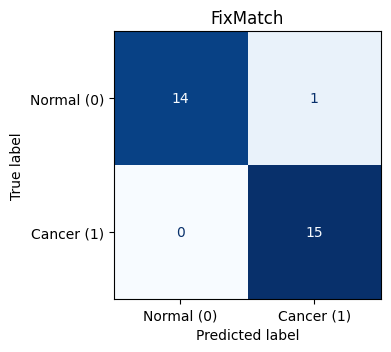

Grad-CAM — FixMatch — FN :
Aucune erreur FN.
Grad-CAM — FixMatch — FP :


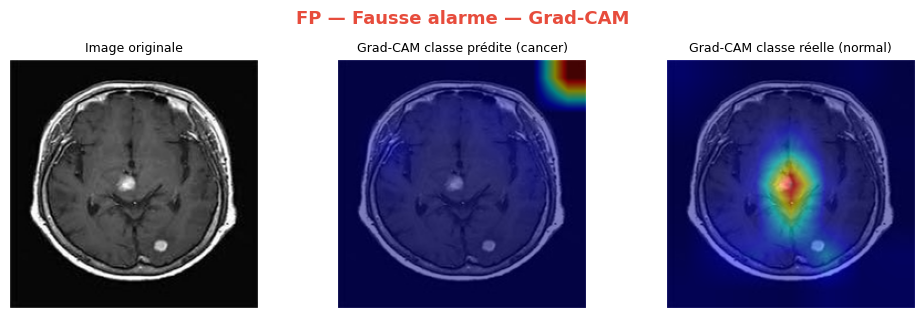

In [19]:
load_checkpoint(model_fm, "fixmatch_best")
y_true_fm, y_pred_fm, _ = predict_loader(model_fm, loader_val)
results_fm = evaluate(y_true_fm, y_pred_fm, title="FixMatch")
run_gradcam_analysis(
    model_fm, labeled_val_df.reset_index(drop=True),
    y_true_fm, y_pred_fm, phase="FixMatch",
)

## 10. Comparaison finale — toutes méthodes incluant les baselines historiques

On évalue **sur le même val set (30 images)** :
- les 3 méthodes SSL nouvelles
- la baseline EfficientNet-B4 supervisée pure
- les 3 anciens modèles MyCNN (`model_phase1.pth`, `model_phase2.pth`, `model_supervised.pth`)


In [20]:
class MyCNN(nn.Module):
    """Identical to Modelisations.ipynb to allow reloading old .pth files."""
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1, bias=False), nn.BatchNorm2d(512), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(512, 256), nn.ReLU(True),
            nn.Dropout(dropout), nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def eval_old_model(filename, name):
    m = MyCNN().to(DEVICE)
    m.load_state_dict(torch.load(PROJECT_ROOT / filename, map_location=DEVICE))
    y, p, _ = predict_loader(m, loader_val)
    return evaluate(y, p, title=name, show_plot=False)


results_phase1 = eval_old_model("model_phase1.pth", "MyCNN Phase 1")
results_phase2 = eval_old_model("model_phase2.pth", "MyCNN Phase 2")
results_phase3 = eval_old_model("model_supervised.pth", "MyCNN Phase 3 (supervisé pur)")

────────────────────────────────────────
  MyCNN Phase 1
────────────────────────────────────────
  Accuracy  : 0.8000
  Precision : 0.8000
  Recall    : 0.8000
  F1-score  : 0.8000
  F2-score  : 0.8000
  ARI       : 0.3371

────────────────────────────────────────
  MyCNN Phase 2
────────────────────────────────────────
  Accuracy  : 0.9000
  Precision : 0.8750
  Recall    : 0.9333
  F1-score  : 0.9032
  F2-score  : 0.9211
  ARI       : 0.6272

────────────────────────────────────────
  MyCNN Phase 3 (supervisé pur)
────────────────────────────────────────
  Accuracy  : 0.8333
  Precision : 0.8125
  Recall    : 0.8667
  F1-score  : 0.8387
  F2-score  : 0.8553
  ARI       : 0.4247



In [21]:
all_results = {
    "MyCNN Phase 1 (pseudo-labels GMM)":        results_phase1,
    "MyCNN Phase 2 (fine-tuning labels forts)": results_phase2,
    "MyCNN Phase 3 (supervisé pur 70)":         results_phase3,
    "EffNet-B4 baseline (supervisé 70)":        results_baseline,
    "EffNet-B4 + Pseudo-Labeling itératif":     results_pl,
    "EffNet-B4 + Mean Teacher":                 results_mt,
    "EffNet-B4 + FixMatch":                     results_fm,
}
df_compare = pd.DataFrame(all_results).T[["accuracy", "precision", "recall", "f1", "f2", "ari"]]
df_compare = df_compare.round(4)
df_compare.to_csv(CHECKPOINT_DIR / "comparison_results.csv")
df_compare.style.background_gradient(cmap="Greens", axis=0).format("{:.4f}")

,accuracy,precision,recall,f1,f2,ari
MyCNN Phase 1 (pseudo-labels GMM),0.8000,0.8000,0.8000,0.8000,0.8000,0.3371
MyCNN Phase 2 (fine-tuning labels forts),0.9000,0.8750,0.9333,0.9032,0.9211,0.6272
MyCNN Phase 3 (supervisé pur 70),0.8333,0.8125,0.8667,0.8387,0.8553,0.4247
EffNet-B4 baseline (supervisé 70),0.9667,1.0000,0.9333,0.9655,0.9459,0.8665
EffNet-B4 + Pseudo-Labeling itératif,0.9667,1.0000,0.9333,0.9655,0.9459,0.8665
EffNet-B4 + Mean Teacher,0.9667,1.0000,0.9333,0.9655,0.9459,0.8665
EffNet-B4 + FixMatch,0.9667,0.9375,1.0000,0.9677,0.9868,0.8665


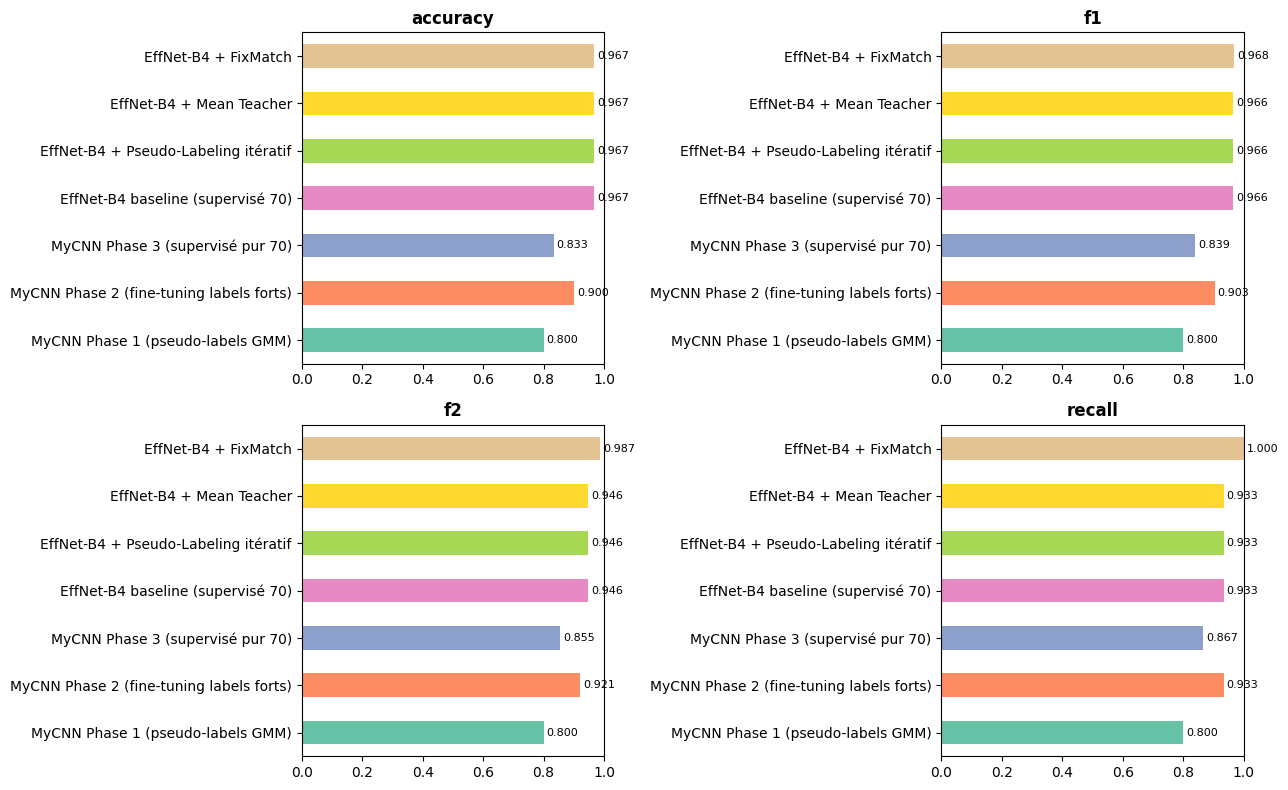

In [22]:
metrics = ["accuracy", "f1", "f2", "recall"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
colors = sns.color_palette("Set2", len(df_compare))
for ax, m in zip(axes.flat, metrics):
    df_compare[m].plot.barh(ax=ax, color=colors)
    ax.set_title(m, fontweight="bold")
    ax.set_xlim(0, 1)
    for i, v in enumerate(df_compare[m]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

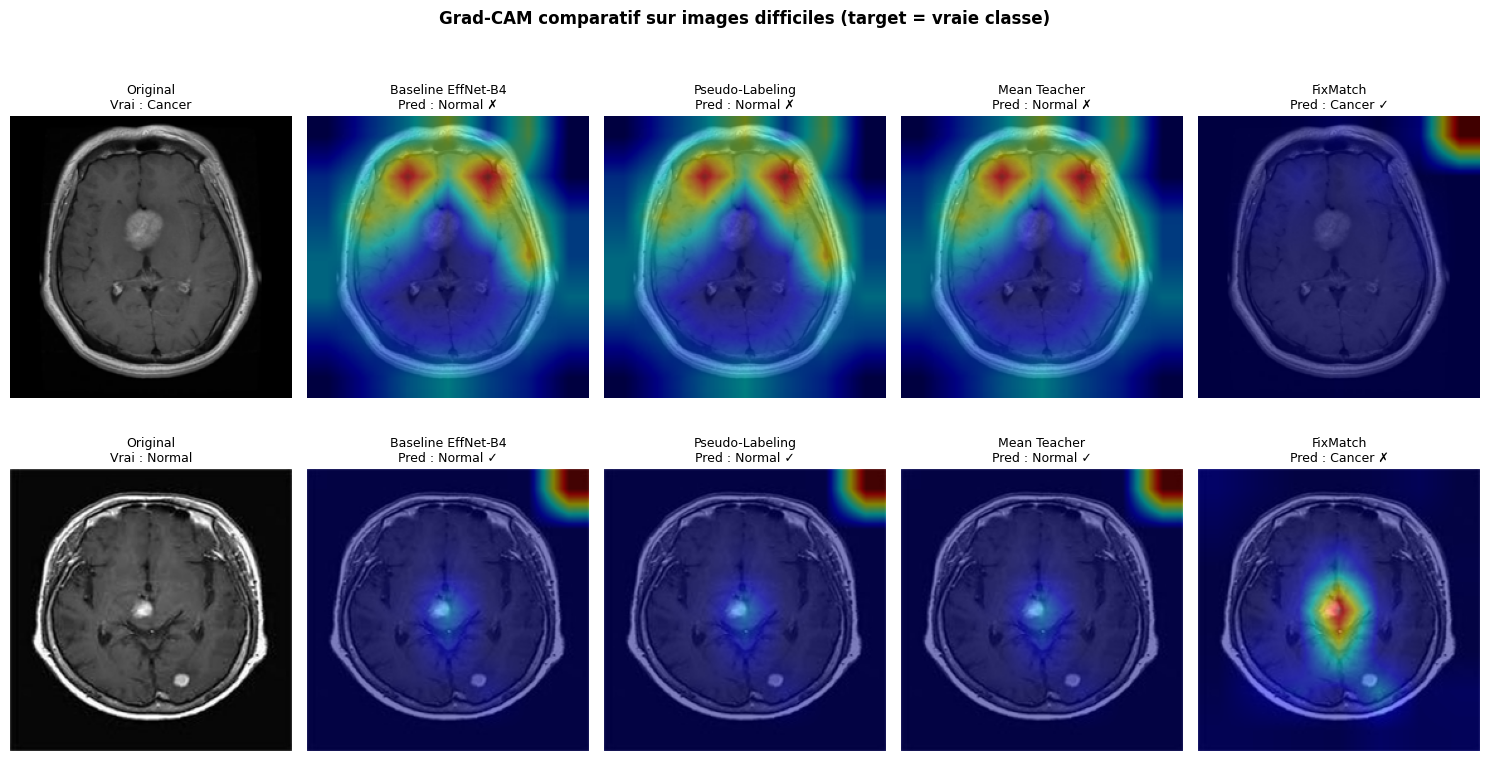

In [23]:
# Pick up to 3 hard val images (at least one model gets it wrong)
preds_all = np.stack([y_pred_b, y_pred_pl, y_pred_mt, y_pred_fm])
hard_idxs = np.where((preds_all != y_true_b[None]).any(axis=0))[0][:3]
if len(hard_idxs) == 0:
    hard_idxs = np.array([0, 1, 2])

models_grid = [
    ("Baseline EffNet-B4", model_baseline),
    ("Pseudo-Labeling",    model_pl),
    ("Mean Teacher",       mt_model),
    ("FixMatch",           model_fm),
]
val_paths = labeled_val_df.reset_index(drop=True)["image_path"].values
val_labels = labeled_val_df.reset_index(drop=True)["label"].values

fig, axes = plt.subplots(len(hard_idxs), len(models_grid) + 1, figsize=(15, 4 * len(hard_idxs)))
if len(hard_idxs) == 1:
    axes = axes[None, :]
for r, idx in enumerate(hard_idxs):
    path = val_paths[idx]
    true_lbl = "Cancer" if val_labels[idx] == 1 else "Normal"
    axes[r][0].imshow(Image.open(path).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    axes[r][0].set_title(f"Original\nVrai : {true_lbl}", fontsize=9)
    axes[r][0].axis("off")
    for c, (name, m) in enumerate(models_grid):
        for p in m.features.parameters(): p.requires_grad_(True)
        with GradCAM(m, m.features[-1]) as gc:
            t = transform_inference(Image.open(path).convert("RGB")).unsqueeze(0).to(DEVICE)
            cam = gc(t.requires_grad_(True), int(val_labels[idx]))
            _, ov = overlay_gradcam(path, cam)
        for p in m.features.parameters(): p.requires_grad_(False)
        pred = preds_all[c, idx]
        ok = "✓" if pred == val_labels[idx] else "✗"
        pred_lbl = "Cancer" if pred == 1 else "Normal"
        axes[r][c + 1].imshow(ov)
        axes[r][c + 1].set_title(f"{name}\nPred : {pred_lbl} {ok}", fontsize=9)
        axes[r][c + 1].axis("off")
plt.suptitle("Grad-CAM comparatif sur images difficiles (target = vraie classe)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

## 11. Conclusion

À compléter après exécution complète. Points à analyser :
- Quelle méthode SSL bat la baseline EfficientNet-B4 supervisée pure ?
- Battent-elles `model_phase2.pth` (0.900 acc, le meilleur ancien modèle) ?
- Mean Teacher converge-t-il sans divergence (`cons_loss` décroissante après rampup) ?
- FixMatch atteint-il un `mask_ratio` > 50% en fin de training ?
- Les Grad-CAM des méthodes SSL sont-ils plus pertinents (focus sur la zone cérébrale) ?

**Limites connues :**
- Val set = 30 images → intervalles de confiance larges
- Backbone gelé → les méthodes SSL agissent uniquement sur la tête de classification, ce qui limite leur potentiel comparé à un fine-tuning end-to-end
- Pas de cross-validation → un seul split, sensibilité au seed
- Pseudo-labels GMM utilisés comme images sans label : si la phase de clustering a un biais, certaines images "faciles" sont surreprésentées
